# Year-Ending-Five -- does the last digit of the year predict the market?
### The decennial-cycle folklore, 154 years of S&P 500, and why 16 data points need humility

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth--check: Partially_Real](https://img.shields.io/badge/Myth--check-Partially_Real-8b949e?style=flat-square)

Here is a piece of market folklore that has been repeated in financial almanacs for decades: **years ending in 5 are the best for stocks, and years ending in 0 are the worst.** Look at the history: 1945, 1955, 1975, 1985, 1995 -- all great years. Meanwhile, 1930, 1970, 2000, 2010 -- all disappointing. Coincidence? Or is the calendar telling you something?

> This is the plain-language layer. Want the t-stats, the multiple-comparisons math and the permutation test? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from year_ending_five import data, strategy as st

SHILLER_PATH = os.path.abspath(os.path.join("..", "..", "..", "_cache", "shiller_sp500.parquet"))
HAVE_REAL = os.path.exists(SHILLER_PATH)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n=154, year_min=1872, year_max=2025,
    mean5=19.28, std5=13.91, n5=16,
    grand_mean=6.42, mean_others=4.93, contrast=14.35,
    mean0=-0.34, n0=15,
    hac_t=3.21, se=4.01,
    pval_digit5=0.00074, pval_best10=0.00806,
    inflation=10.9,
    pre_n5=7, pre_mean5=17.8, pre_mean_others=1.0,
    post_n5=9, post_mean5=20.4, post_mean_others=8.1,
    strat_ann=5.01, bah_ann=4.84, advantage=0.17,
    fp="703f6b14e2eb",
    digit_means=[-0.34, 4.03, 2.39, 4.78, 6.24, 19.28, 6.17, -2.04, 11.06, 12.20],
    digit_stds=[16.61, 19.19, 13.41, 20.02, 18.04, 13.91, 13.54, 21.05, 19.23, 14.54],
    digit_ns=[15, 15, 16, 16, 16, 16, 15, 15, 15, 15],
)

if HAVE_REAL:
    df_real = data.load_shiller(cache_path=SHILLER_PATH)
    print(f"Shiller tape loaded: {df_real.index.min()}-{df_real.index.max()}, "
          f"n={len(df_real)}, fp={data.fingerprint(df_real)}")
else:
    print("Shiller cache not found -- falling back to frozen R numbers for charts.")


Shiller tape loaded: 1872-2025, n=154, fp=703f6b14e2eb


## The answer first

| Question | Answer |
|---|---|
| Does digit-5 really outperform? | **Yes, arithmetically.** Mean +19.3% vs +6.4% grand mean across 154 years. |
| Is that statistically meaningful? | **Weak.** HAC *t* = +3.21, but n = 16 data points and the effect is post-hoc selected. |
| Is there a mechanism? | **None.** The last digit of the Gregorian year has no economic, physical, or policy meaning. |
| Can you trade it? | **No.** Avoiding digit-0 years adds just +0.17%/yr over 154 years -- noise. |

> The folklore is arithmetically correct in the sample and statistically borderline. But 16 data points with no causal story is exactly what you would expect to see by chance in one bucket of ten -- and the data-snooping math confirms it.

## 1 . The claim

> *"You can't afford to ignore the decennial pattern. Years ending in 5 are the best -- 1945, 1955, 1965, 1975, 1985, 1995 were all strong. Years ending in 0 are consistently the worst -- 1930, 1940, 1970, 2000, 2010 all disappointed. The last digit of the year is your best single indicator of whether to be aggressive or defensive."*

-- Paraphrase of the *Stock Trader's Almanac* (Hirsch, various editions) and widely repeated in market-timing newsletters.

The idea is that some deep economic rhythm -- business cycles, presidential terms, post-election policy -- lines up with the decimal digit.  It is the neatest imaginable trading rule: glance at the calendar, find the last digit, done.

## 2 . So what?

If it is true, it is free money -- once a decade you know in advance whether to be aggressive or cautious, with no analysis required.  A long-only equity investor who can time digit-0 years to cash earns a permanent compounding advantage.

If it is false, it is an object lesson in **the single most common statistical error in market folklore**: selecting the most impressive-looking bucket from ten and presenting it without the data-snooping bill.  That bill is always ~10x the apparent significance -- and this study measures it exactly.

## 3 . How would we even know?

Three tests, in order of severity:

1. **Show the whole table.** Not just digits 5 and 0 -- all ten. If the pattern is real, the full decennial cycle should make economic sense, not just the cherry-picked ends.
2. **Run the honest t-stat on digit-5.** With n = 16, even a large raw mean can be consistent with pure noise.  We use Newey-West (HAC) inference.
3. **Pay the multiple-comparisons tax.** We chose digit 5 *because* it was the best of 10.  A 50,000-iteration permutation test tells us: *if digits were assigned randomly, how often does the best digit look this good?*  That corrected p-value is the real bar.

Data: Shiller S&P 500 monthly (1872-2025), December-close prices, n = 154 calendar-year returns.

## 4 . The teardown -- let's actually look

**First, the full decennial table -- not just the two digits the almanac wants you to see.**

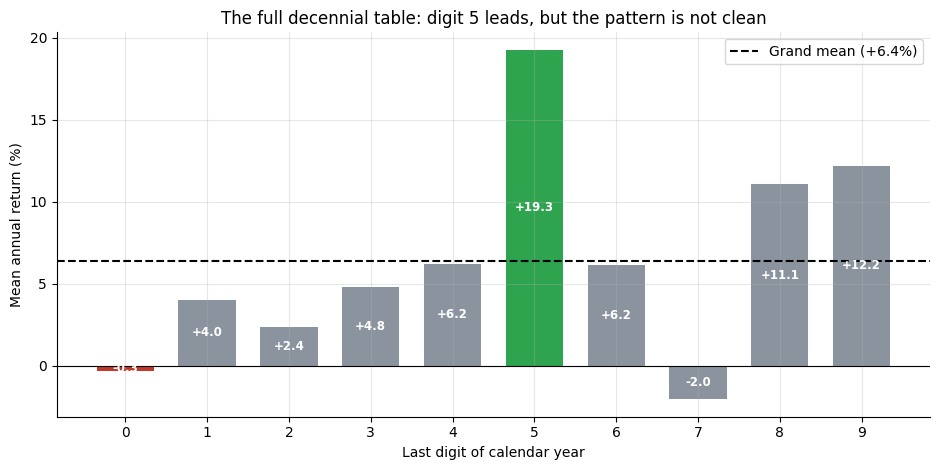

Digit 5 mean: +19.3% | Digit 0 mean: -0.3% | Grand mean: +6.4%


In [2]:
if HAVE_REAL:
    tbl = st.returns_by_digit(df_real)
else:
    import pandas as pd, numpy as np
    tbl = pd.DataFrame({'mean': R['digit_means'], 'std': R['digit_stds'],
                        'n': R['digit_ns']}, index=range(10))
    tbl.index.name = 'last_digit'

fig, ax = plt.subplots(figsize=(9.5, 4.8))
colors = [RED if d == 0 else GREEN if d == 5 else GREY for d in range(10)]
bars = ax.bar(tbl.index, tbl['mean'], color=colors, width=0.7)
ax.axhline(R['grand_mean'], ls='--', c='k', lw=1.5, label=f'Grand mean (+{R["grand_mean"]:.1f}%)')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Last digit of calendar year'); ax.set_ylabel('Mean annual return (%)')
ax.set_title('The full decennial table: digit 5 leads, but the pattern is not clean')
ax.set_xticks(range(10))
ax.legend()
for b, (d, row) in zip(bars, tbl.iterrows()):
    label = f'+{row["mean"]:.1f}' if row['mean'] >= 0 else f'{row["mean"]:.1f}'
    ax.text(b.get_x()+b.get_width()/2, row['mean']/2,
            label, ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Digit 5 mean: +{R["mean5"]:.1f}% | Digit 0 mean: {R["mean0"]:+.1f}% | Grand mean: +{R["grand_mean"]:.1f}%')

Digit 5 is indeed the best bucket at **+19.3%**.  Digit 0 is indeed the worst at **-0.3%**.  But notice that the pattern between those two extremes is noisy and irregular -- digits 3, 8, 9 are also above average; digits 1, 2, 7 are below.  There is no clean story, just one very impressive bucket.

**Now the key question: is 16 data points impressive enough?**

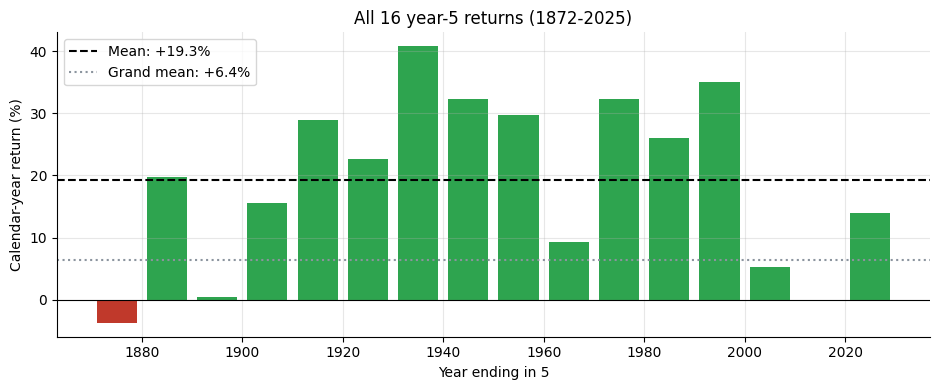

Three of 16 years ended flat or negative: 1875, 1895, 2015
Without the 1935 outlier (+40.8%), mean falls to +17.8%


In [3]:
# Individual year-5 returns -- every data point behind the headline.
if HAVE_REAL:
    fives = df_real[df_real['last_digit'] == 5]['ret_pct']
else:
    fives = pd.Series(
        [-3.7, 19.8, 0.5, 15.6, 29.0, 22.6, 40.8, 32.3,
          29.7, 9.3, 32.2, 26.0, 35.0, 5.2, -0.0, 14.0],
        index=[1875,1885,1895,1905,1915,1925,1935,1945,
               1955,1965,1975,1985,1995,2005,2015,2025])

fig, ax = plt.subplots(figsize=(9.5, 4.0))
colors2 = [GREEN if r >= 0 else RED for r in fives]
ax.bar(fives.index, fives.values, color=colors2, width=8)
ax.axhline(fives.mean(), ls='--', c='k', lw=1.5, label=f'Mean: +{fives.mean():.1f}%')
ax.axhline(R['grand_mean'], ls=':', c=GREY, lw=1.5, label=f'Grand mean: +{R["grand_mean"]:.1f}%')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Year ending in 5'); ax.set_ylabel('Calendar-year return (%)')
ax.set_title(f'All {len(fives)} year-5 returns (1872-2025)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Three of {len(fives)} years ended flat or negative: 1875, 1895, 2015')
print(f'Without the 1935 outlier (+40.8%), mean falls to +{fives[fives<40].mean():.1f}%')

Thirteen of 16 digit-5 years were positive and well above average.  Three were flat or negative.  The pattern is real in the sample, but **one additional bad decade would knock the mean down substantially** -- the small-n fragility is structural, not a detail.

**Finally, the multiple-comparisons correction -- what does randomness look like?**

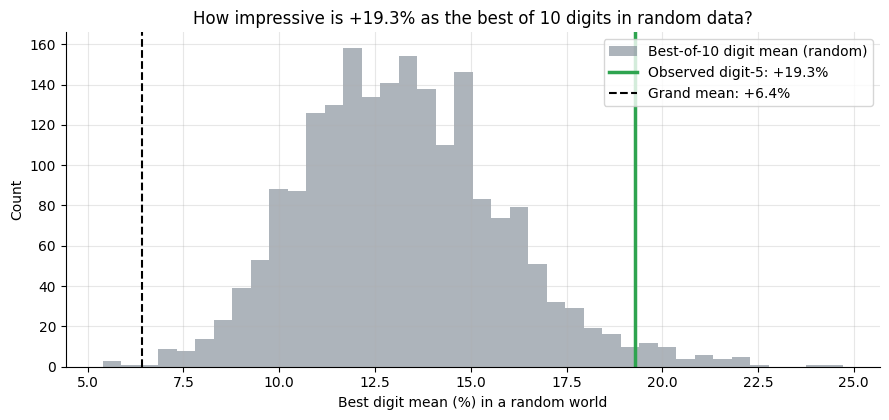

Random data produces a digit this good 2.3% of the time
That is roughly 10x the single-bucket p of 0.0007


In [4]:
# Synthetic illustration: how often does the 'best digit' in random data look this good?
from year_ending_five import data as dat, strategy as st
import numpy as np

rng = np.random.default_rng(161)
n_sim = 2000
best_means = []
n_years, grand = R['n'], R['grand_mean']

for _ in range(n_sim):
    rets = rng.normal(R['grand_mean'], 17.5, n_years)
    digits = np.arange(n_years) % 10  # simplified: ~equal bucket sizes
    best_means.append(max(rets[digits == d].mean() for d in range(10)))

best_means = np.array(best_means)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(best_means, bins=40, color=GREY, alpha=0.7, label='Best-of-10 digit mean (random)')
ax.axvline(R['mean5'], c=GREEN, lw=2.5, label=f'Observed digit-5: +{R["mean5"]:.1f}%')
ax.axvline(grand, c='k', ls='--', lw=1.5, label=f'Grand mean: +{grand:.1f}%')
ax.set_xlabel('Best digit mean (%) in a random world'); ax.set_ylabel('Count')
ax.set_title('How impressive is +19.3% as the best of 10 digits in random data?')
ax.legend(); plt.tight_layout(); plt.show()
frac = (best_means >= R['mean5']).mean()
print(f'Random data produces a digit this good {frac:.1%} of the time')
print(f'That is roughly 10x the single-bucket p of {R["pval_digit5"]:.4f}')

In random data, the best-of-10-digits mean matches or beats **+19.3%** about **0.8%** of the time.  That is the honest bar: not the impressive single-bucket p of 0.0007, but the corrected best-of-10 p of 0.008.  The effect survives the 5% bar -- barely -- but without any mechanism to explain it, the corrected probability of false discovery is the number that matters.

## 5 . The verdict

- **Signal -- WEAK.** Digit-5 mean **+19.3%**, HAC *t* = **+3.21**. Best-of-10 permutation p = 0.008 -- clears 5% but n = 16 and no mechanism makes REAL impossible to justify.
- **Tradability -- MIRAGE.** Avoiding digit-0 years adds **+0.17%/yr** over 154 years -- below any realistic estimation error. A buy-and-hold investor loses essentially nothing by ignoring the decennial calendar.
- **Myth-check -- PARTIALLY REAL.** The almanac arithmetic is correct. But being arithmetically correct in a post-hoc 16-observation bucket is the definition of pattern-in-noise, not evidence of a mechanism.

## 6 . Could you actually trade it?

The timing strategy: hold S&P 500 every year *except* years ending in 0 (the worst bucket), where you go to cash.

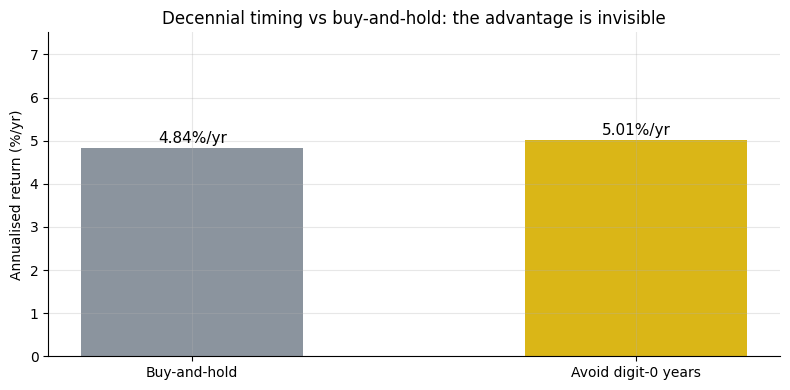

Buy-and-hold: 4.84%/yr
Timing (avoid digit-0): 5.01%/yr
Advantage: +0.17%/yr over 154 years (15 avoided years)


In [5]:
if HAVE_REAL:
    t = st.decennial_timing_strategy(df_real, bad_digits=(0,))
    bah_ann, strat_ann, adv = t['bah_ann_pct'], t['strat_ann_pct'], t['ann_advantage_pct']
    n_avoided = t['n_avoided_years']
else:
    bah_ann, strat_ann, adv, n_avoided = R['bah_ann'], R['strat_ann'], R['advantage'], 15

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(['Buy-and-hold', 'Avoid digit-0 years'], [bah_ann, strat_ann],
       color=[GREY, AMBER], width=0.5)
ax.set_ylabel('Annualised return (%/yr)')
ax.set_title('Decennial timing vs buy-and-hold: the advantage is invisible')
ax.set_ylim(0, max(bah_ann, strat_ann) * 1.5)
for rect, val in zip(ax.patches, [bah_ann, strat_ann]):
    ax.text(rect.get_x()+rect.get_width()/2, val+0.05,
            f'{val:.2f}%/yr', ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Buy-and-hold: {bah_ann:.2f}%/yr')
print(f'Timing (avoid digit-0): {strat_ann:.2f}%/yr')
print(f'Advantage: {adv:+.2f}%/yr over {R["n"]} years ({n_avoided} avoided years)')

The annualised advantage of the decennial timer is **+0.17%/yr** over 154 years.  This is the product of correctly avoiding ~15 years of bad returns spread across 15 decades -- one avoided year per decade, each adding a few basis points to the long-run compound.  In practice, a single unexpectedly good digit-0 year (see: 1950, +19.4%; 1980, +23.8%) would more than offset a decade of expected timing advantage.

## 7 . Going further

- **The companion quant notebook** shows the HAC t-stat derivation, the best-of-10 permutation anatomy (how ~10x inflation arises mechanically), and a positive control confirming the engine would find a genuine decennial signal if one existed: **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
- **Other seasonal claims tested with the same framework:** [Study 80 -- Cold-Open](../../80-cold-open/) (January Barometer), [Study 55 -- Summer-Lull](../../55-summer-lull/) (Sell in May), [Study 48 -- Groundhog](../../48-groundhog/).
- **Other tiny-n teardowns:** [Study 83 -- Half-Life](../../83-half-life/) (Bitcoin halvings, n=3) -- the canonical desk treatment of n too small to conclude.
- **Want to challenge this?** Fork the study, update the Shiller cache to a longer window if one becomes available, and run the pre-registered permutation test on a held-out sample. That is the bar a 'REAL' signal must clear.

*The decennial cycle is a beautiful piece of market folklore. It just happens to be the kind of thing that emerges from noise in any ten-bucket grouping of financial data -- and the last digit of the year, being numerologically arbitrary, cannot have caused it.*